In [1]:
%pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
Path("../dataset_trabalho")

WindowsPath('../dataset_trabalho')

In [15]:
from pathlib import Path

base = Path("../dataset_trabalho")

classe_saudavel = "orange"
classe_podre = "rottenoranges"

pasta_saudavel = base / classe_saudavel
pasta_podre = base / classe_podre

imagens_saudaveis = sorted(list(pasta_saudavel.glob("*")))
imagens_podres = sorted(list(pasta_podre.glob("*")))

print("Pasta saudável:", pasta_saudavel)
print("Existe?", pasta_saudavel.exists())
print("Saudáveis:", len(imagens_saudaveis))

print("Pasta podre:", pasta_podre)
print("Existe?", pasta_podre.exists())
print("Podres:", len(imagens_podres))

Pasta saudável: ..\dataset_trabalho\orange
Existe? True
Saudáveis: 100
Pasta podre: ..\dataset_trabalho\rottenoranges
Existe? True
Podres: 100


# Método 1 — HSV por saturação

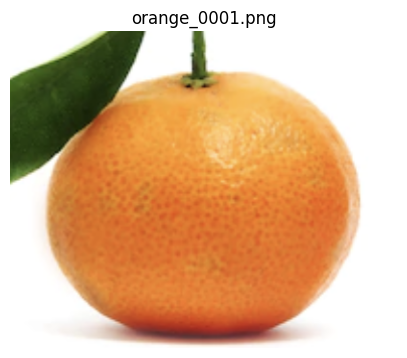

In [16]:
import cv2
import matplotlib.pyplot as plt

caminho_img = imagens_saudaveis[0]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(caminho_img.name)
plt.axis("off")
plt.show()

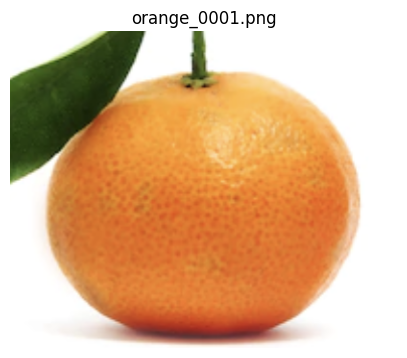

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# pega uma imagem saudável
caminho_img = imagens_saudaveis[0]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(caminho_img.name)
plt.axis("off")
plt.show()

In [28]:
# Converte de BGR para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa os canais H, S e V
h, s, v = cv2.split(img_hsv)

# Máscara pegando regiões mais coloridas
mascara = cv2.inRange(s, 40, 255)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

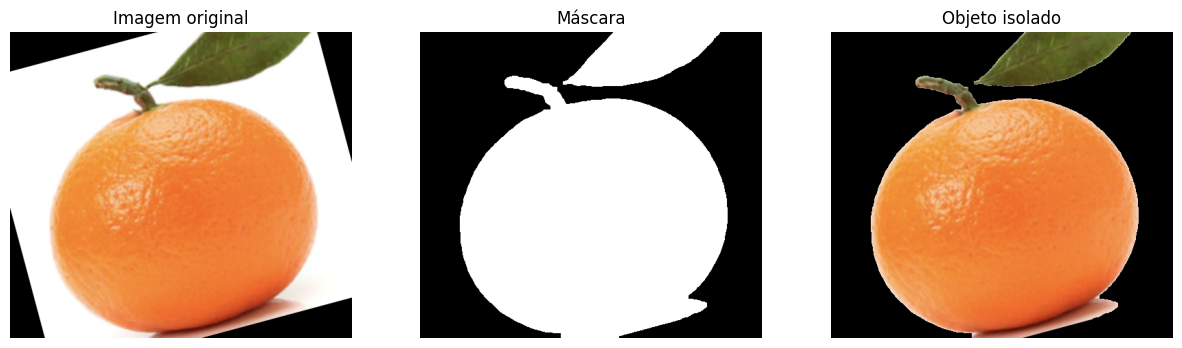

In [29]:
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

In [ ]:
# Agora vamos testar com uma laranja podre
caminho_img = imagens_podres[0]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa canais
h, s, v = cv2.split(img_hsv)

# Cria a máscara pela saturação
mascara = cv2.inRange(s, 40, 255)

# Limpa a máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original - podre")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

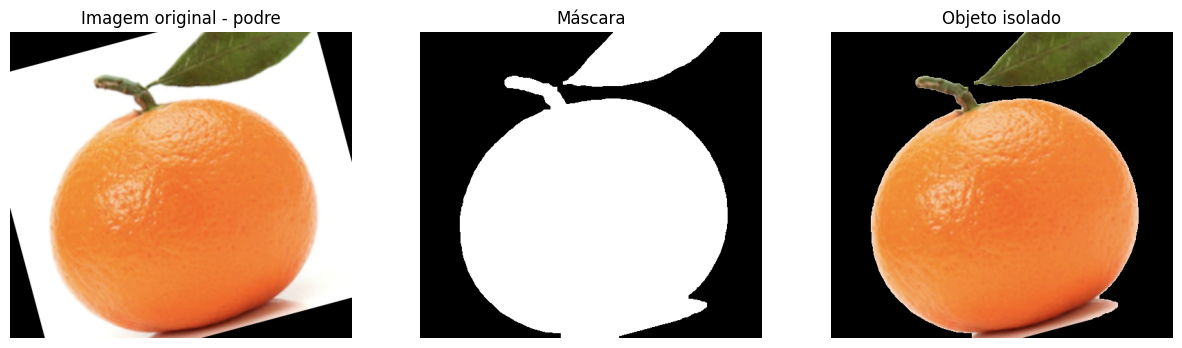

In [40]:

caminho_img = imagens_saudaveis[0]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa canais
h, s, v = cv2.split(img_hsv)

# Cria a máscara pela saturação
mascara = cv2.inRange(s, 40, 255)

# Limpa a máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original - podre")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

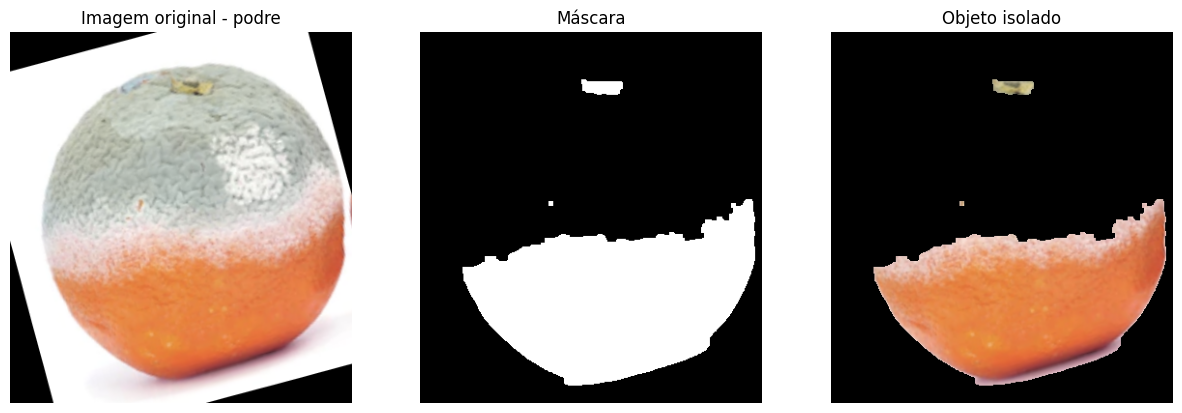

In [31]:
# Agora vamos testar com uma laranja podre
caminho_img = imagens_podres[1]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa canais
h, s, v = cv2.split(img_hsv)

# Cria a máscara pela saturação
mascara = cv2.inRange(s, 40, 255)

# Limpa a máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original - podre")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

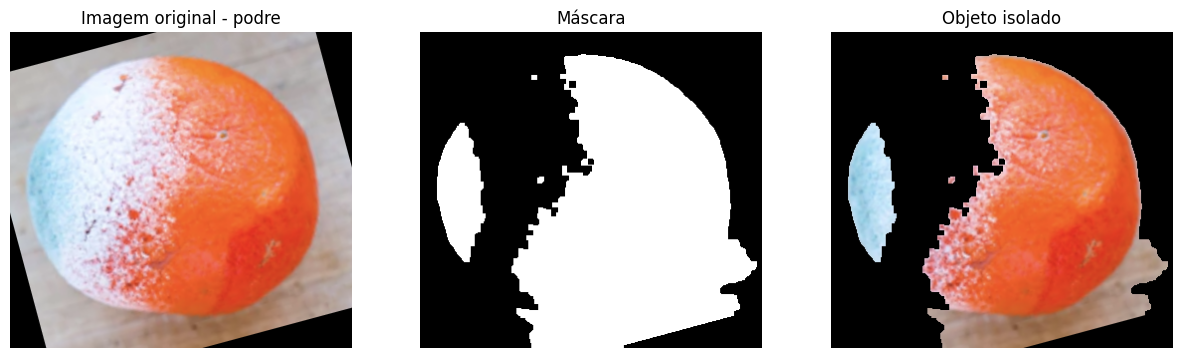

In [32]:
# Agora vamos testar com uma laranja podre
caminho_img = imagens_podres[10]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa canais
h, s, v = cv2.split(img_hsv)

# Cria a máscara pela saturação
mascara = cv2.inRange(s, 40, 255)

# Limpa a máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original - podre")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

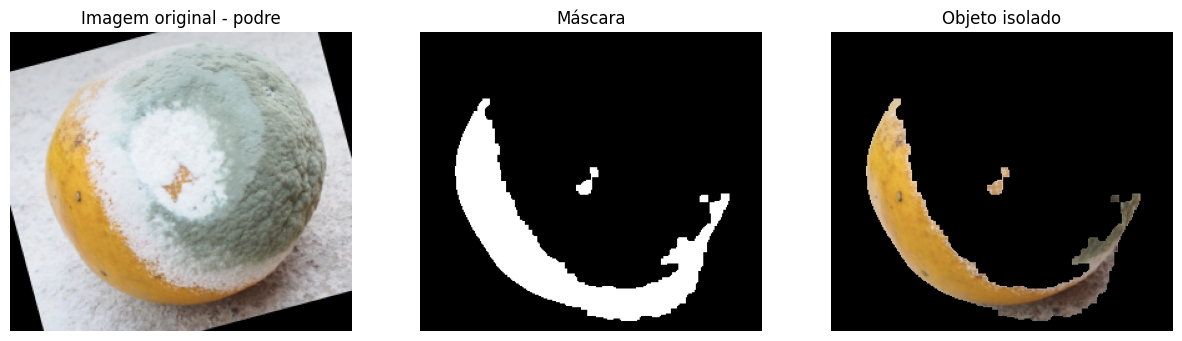

In [33]:
# Agora vamos testar com uma laranja podre
caminho_img = imagens_podres[98]

img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separa canais
h, s, v = cv2.split(img_hsv)

# Cria a máscara pela saturação
mascara = cv2.inRange(s, 40, 255)

# Limpa a máscara
kernel = np.ones((5, 5), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara
resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original - podre")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_limpa, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

# metodo 2


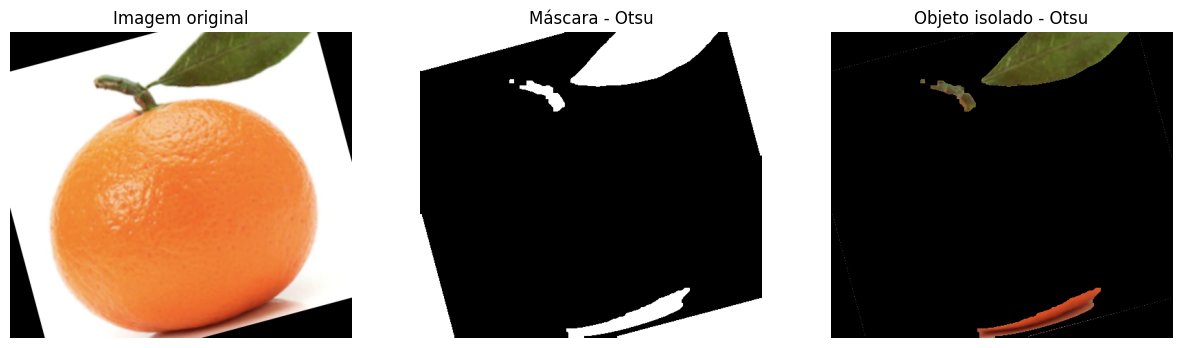

In [34]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_saudaveis[0]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

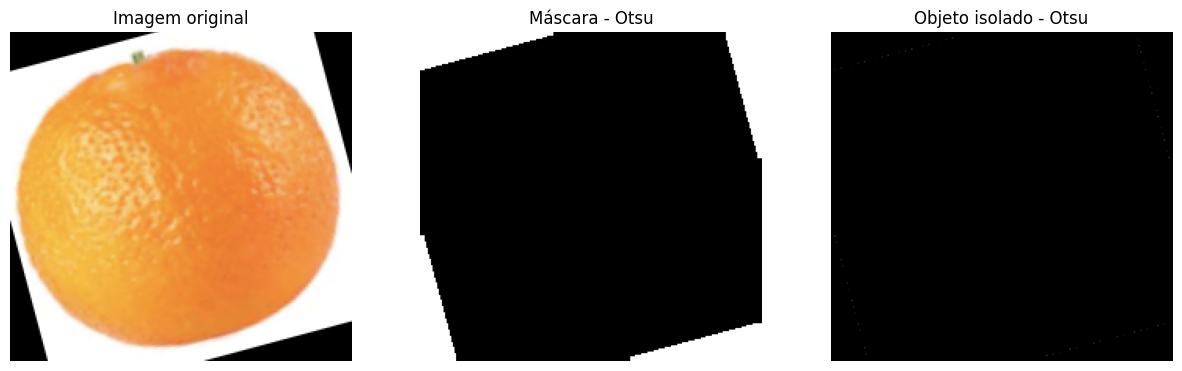

In [38]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_saudaveis[1]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

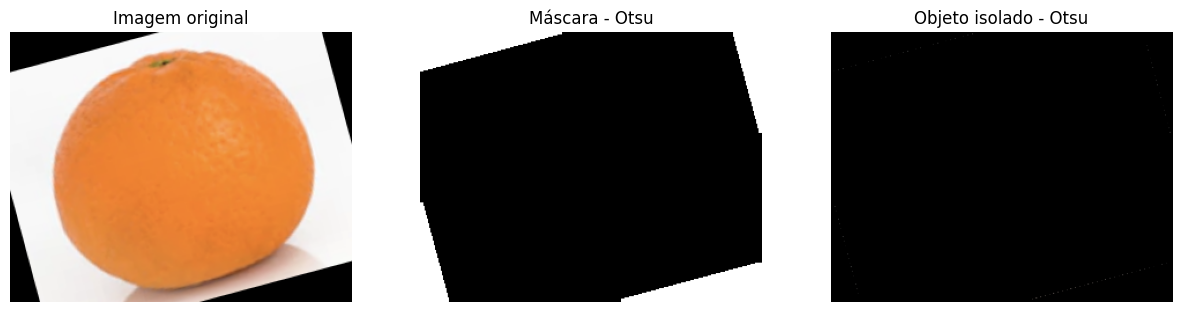

In [39]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_saudaveis[10]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

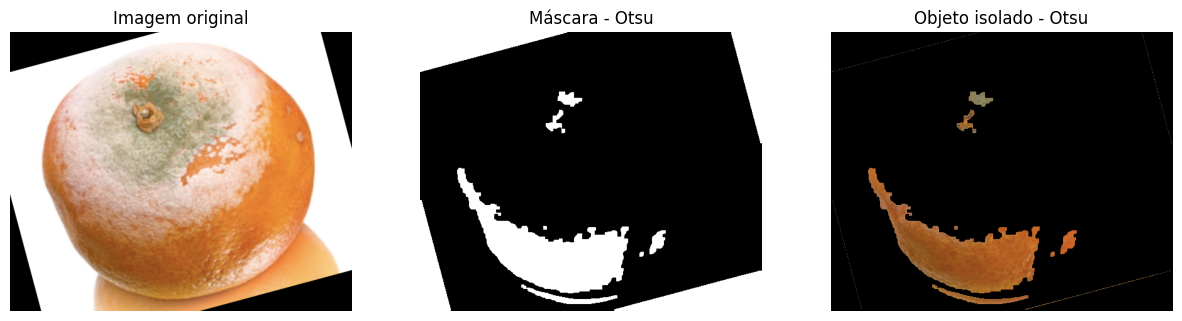

In [35]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_podres[0]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

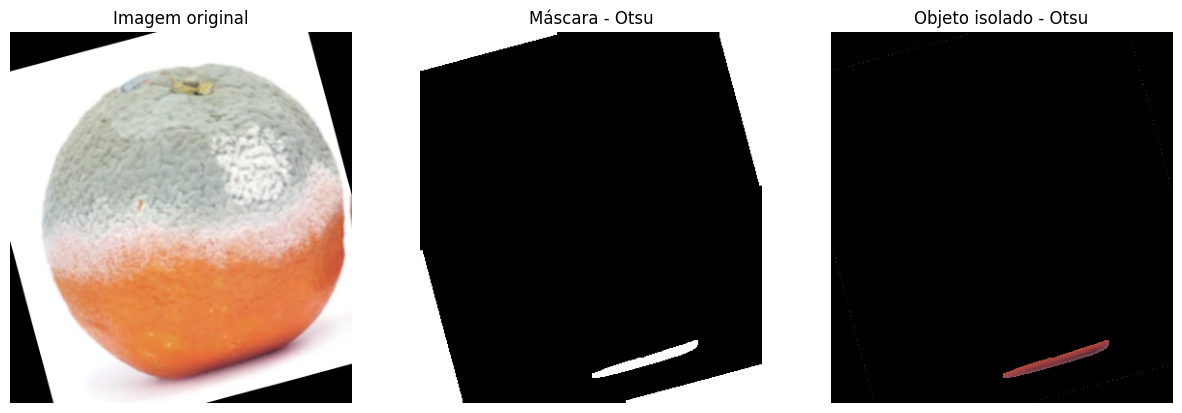

In [36]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_podres[1]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

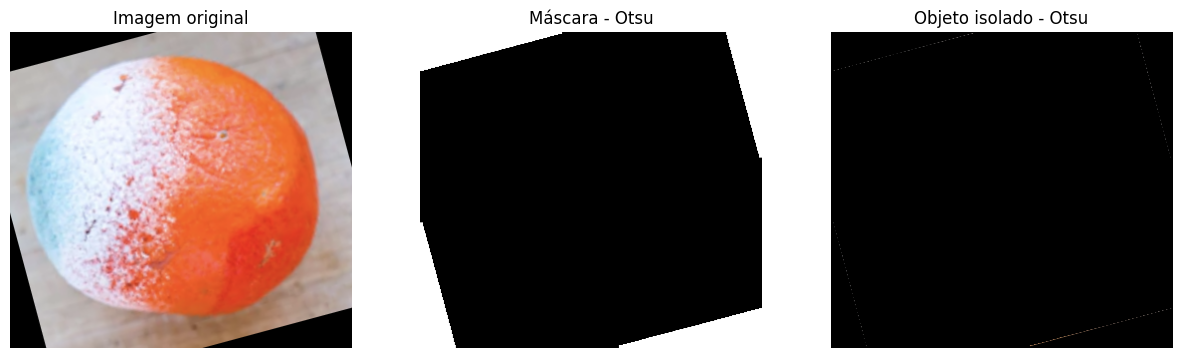

In [37]:
# MÉTODO 2 - Threshold em escala de cinza com Otsu

# Escolhe uma imagem saudável
caminho_img = imagens_podres[10]

# Lê a imagem
img_bgr = cv2.imread(str(caminho_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converte para escala de cinza
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplica um leve desfoque para reduzir ruídos
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplica Otsu
# Como o fundo é claro, usamos THRESH_BINARY_INV para deixar a fruta branca e o fundo preto
_, mascara_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Limpeza da máscara
kernel = np.ones((5, 5), np.uint8)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu, cv2.MORPH_OPEN, kernel)
mascara_otsu_limpa = cv2.morphologyEx(mascara_otsu_limpa, cv2.MORPH_CLOSE, kernel)

# Aplica a máscara na imagem original
resultado_otsu = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_otsu_limpa)

# Mostra os resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara_otsu_limpa, cmap="gray")
plt.title("Máscara - Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado_otsu)
plt.title("Objeto isolado - Otsu")
plt.axis("off")

plt.show()

# Conclusão da segmentação

Foram comparados dois métodos de segmentação: HSV por saturação e threshold em escala de cinza com Otsu.

O método HSV apresentou melhor resultado visual, pois conseguiu separar melhor a laranja do fundo branco, preservando a maior parte do objeto. A principal limitação foi incluir regiões como folha e caule em algumas imagens.

O método Otsu foi mais simples e automático, mas apresentou pior desempenho em imagens com brilho, sombras e regiões claras de podridão. Em alguns casos, ele capturou apenas partes escuras da fruta, perdendo grande parte do objeto.

Por isso, o método HSV por saturação foi escolhido como principal para seguir nas próximas etapas do projeto.